#### `Import Libraries`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### `Questions`
> Merge all 3 DataFrames and validate the combined dataset

> Detect overpriced properties using the IQR method per city

> Which city has the highest price growth rate (%) over the recorded period?

> Build a property investment score using `np.select()` based on Rating + Price Growth

> What is the correlation between locality rating and property price?

> Create a pivot table — average price per property type per city

> Which city-property type has the highest ROI potential = `(Price_Growth_% / Price_Per_Sqft) × 1000`

> Monthly price trend with 3-month rolling average per city

In [2]:
# ── Dataset 1 — Property Listings ──────────────────────────────
listings_data = {
    'Property_ID': ['PR01','PR02','PR03','PR04','PR05','PR06','PR07','PR08',
                    'PR09','PR10','PR11','PR12','PR13','PR14','PR15',
                    'PR16','PR17','PR18','PR19','PR20','PR21','PR22','PR23','PR24'],

    'City':        ['Mumbai','Mumbai','Mumbai','Mumbai','Mumbai','Mumbai',
                    'Delhi','Delhi','Delhi','Delhi','Delhi','Delhi',
                    'Bangalore','Bangalore','Bangalore','Bangalore','Bangalore','Bangalore',
                    'Hyderabad','Hyderabad','Hyderabad','Hyderabad','Hyderabad','Hyderabad'],

    'Locality':    ['Bandra','Andheri','Juhu','Worli','Dadar','Kurla',
                    'CP','Dwarka','Rohini','Saket','Vasant Kunj','Noida Ext',
                    'Koramangala','Whitefield','HSR Layout','Marathahalli','Indiranagar','Bellandur',
                    'Banjara Hills','Jubilee Hills','Gachibowli','Madhapur','HITEC City','Kondapur'],

    'Property_Type': ['Apartment','Villa','Apartment','Penthouse','Apartment','Apartment',
                      'Apartment','Apartment','Apartment','Villa','Apartment','Apartment',
                      'Apartment','Villa','Apartment','Apartment','Penthouse','Apartment',
                      'Villa','Penthouse','Apartment','Apartment','Apartment','Apartment'],

    'Price_Per_Sqft': [28000,45000,32000,85000,22000,18000,
                       15000,9000,8500,22000,18000,6500,
                       12000,18000,14000,10000,25000,9500,
                       8000,15000,11000,12500,13000,7500],

    'Area_Sqft':   [850,2200,950,3500,780,650,
                    900,1100,980,2800,1050,720,
                    1000,2500,1100,850,2800,750,
                    2200,3200,1050,980,1100,820],

    'Listing_Month': ['2024-01','2024-01','2024-02','2024-02','2024-03','2024-03',
                      '2024-01','2024-01','2024-02','2024-02','2024-03','2024-03',
                      '2024-01','2024-01','2024-02','2024-02','2024-03','2024-03',
                      '2024-01','2024-01','2024-02','2024-02','2024-03','2024-03']
}

In [3]:
# ── Dataset 2 — Historical Price Growth ────────────────────────
growth_data = {
    'City':             ['Mumbai','Delhi','Bangalore','Hyderabad'],
    'Price_Growth_%':   [18.5,    12.3,   22.8,        28.6],
    'Avg_Rental_Yield': [3.2,     4.1,    5.8,         6.4]
}

In [4]:
# ── Dataset 3 — Locality Ratings ───────────────────────────────
ratings_data = {
    'Locality': ['Bandra','Andheri','Juhu','Worli','Dadar','Kurla',
                 'CP','Dwarka','Rohini','Saket','Vasant Kunj','Noida Ext',
                 'Koramangala','Whitefield','HSR Layout','Marathahalli','Indiranagar','Bellandur',
                 'Banjara Hills','Jubilee Hills','Gachibowli','Madhapur','HITEC City','Kondapur'],

    'Locality_Rating': [9.2, 7.8, 9.0, 9.5, 7.2, 6.5,
                        9.0, 7.5, 6.8, 8.5, 8.8, 6.0,
                        9.1, 8.2, 8.6, 7.4, 9.3, 7.0,
                        8.8, 9.2, 8.5, 8.0, 8.3, 7.2],

    'Infrastructure_Score': [9.0, 7.5, 8.8, 9.2, 7.0, 6.2,
                              9.1, 7.2, 6.5, 8.3, 8.5, 5.8,
                              9.0, 8.0, 8.4, 7.2, 9.1, 6.8,
                              8.5, 9.0, 8.3, 7.8, 8.1, 7.0]
}

#### `Step 1 :- Load and Explore Data`

In [5]:
# Convert to DataFrame
data_frame_listings = pd.DataFrame(listings_data)

data_frame_listings

,Property_ID,City,Locality,Property_Type,Price_Per_Sqft,Area_Sqft,Listing_Month
0,PR01,Mumbai,Bandra,Apartment,28000,850,2024-01
1,PR02,Mumbai,Andheri,Villa,45000,2200,2024-01
2,PR03,Mumbai,Juhu,Apartment,32000,950,2024-02
3,PR04,Mumbai,Worli,Penthouse,85000,3500,2024-02
4,PR05,Mumbai,Dadar,Apartment,22000,780,2024-03
5,PR06,Mumbai,Kurla,Apartment,18000,650,2024-03
6,PR07,Delhi,CP,Apartment,15000,900,2024-01
7,PR08,Delhi,Dwarka,Apartment,9000,1100,2024-01
8,PR09,Delhi,Rohini,Apartment,8500,980,2024-02
9,PR10,Delhi,Saket,Villa,22000,2800,2024-02


In [6]:
# Convert to DataFrame
data_frame_growth = pd.DataFrame(growth_data)

data_frame_growth

,City,Price_Growth_%,Avg_Rental_Yield
0,Mumbai,18.5,3.2
1,Delhi,12.3,4.1
2,Bangalore,22.8,5.8
3,Hyderabad,28.6,6.4


In [7]:
# Convert to DataFrame
data_frame_ratings = pd.DataFrame(ratings_data)

data_frame_ratings

,Locality,Locality_Rating,Infrastructure_Score
0,Bandra,9.2,9.0
1,Andheri,7.8,7.5
2,Juhu,9.0,8.8
3,Worli,9.5,9.2
4,Dadar,7.2,7.0
5,Kurla,6.5,6.2
6,CP,9.0,9.1
7,Dwarka,7.5,7.2
8,Rohini,6.8,6.5
9,Saket,8.5,8.3


#### `Step 2 :- Pre-Merge Validation`

In [8]:
# Check shapes and columns before merge
print(f'Listings: {data_frame_listings.shape}')

print(f'Growth: {data_frame_growth.shape}')

print(f'Ratings: {data_frame_ratings.shape}')

print(f'\nListings Columns:\n{data_frame_listings.columns.tolist()}')

print(f'\nGrowth Columns:\n{data_frame_growth.columns.tolist()}')

print(f'\nRatings Columns:\n{data_frame_ratings.columns.tolist()}')

Listings: (24, 7)
Growth: (4, 3)
Ratings: (24, 3)

Listings Columns:
['Property_ID', 'City', 'Locality', 'Property_Type', 'Price_Per_Sqft', 'Area_Sqft', 'Listing_Month']

Growth Columns:
['City', 'Price_Growth_%', 'Avg_Rental_Yield']

Ratings Columns:
['Locality', 'Locality_Rating', 'Infrastructure_Score']


#### `Step 3 :- Three-Table Merge`

In [9]:
# Merge listings with ratings on Locality
data_frame_merged = pd.merge(data_frame_listings, data_frame_ratings, on = 'Locality', how = 'left')

# Merge result with growth data on City
data_frame_merged = pd.merge(data_frame_merged, data_frame_growth, on = 'City', how = 'left')

# Print final shape and check for null values
print(f'Shape after merging: {data_frame_merged.shape}')

print(f'\nNulls:\n{data_frame_merged.isnull().sum()}')

Shape after merging: (24, 11)

Nulls:
Property_ID             0
City                    0
Locality                0
Property_Type           0
Price_Per_Sqft          0
Area_Sqft               0
Listing_Month           0
Locality_Rating         0
Infrastructure_Score    0
Price_Growth_%          0
Avg_Rental_Yield        0
dtype: int64


#### `Step 4 :- Total Property Value`

In [10]:
# Calculate total property value = Price per sqft × Area
data_frame_merged['Total_Property_Value'] = data_frame_merged['Price_Per_Sqft'] * data_frame_merged['Area_Sqft']

print(data_frame_merged[['Property_ID', 'City', 'Price_Per_Sqft', 'Area_Sqft', 'Total_Property_Value']].head())

  Property_ID    City  Price_Per_Sqft  Area_Sqft  Total_Property_Value
0        PR01  Mumbai           28000        850              23800000
1        PR02  Mumbai           45000       2200              99000000
2        PR03  Mumbai           32000        950              30400000
3        PR04  Mumbai           85000       3500             297500000
4        PR05  Mumbai           22000        780              17160000


#### `Step 5 :- IQR Outlier Detection`

In [11]:
# Calculate IQR bounds for Price_Per_Sqft
Q1 = data_frame_merged['Price_Per_Sqft'].quantile(0.25)

Q3 = data_frame_merged['Price_Per_Sqft'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

# Flag overpriced properties
data_frame_merged['Price_Flag'] = np.where(data_frame_merged['Price_Per_Sqft'] > upper_bound, 'Overpriced', 'Fair Value')

print(f'IQR Bounds: Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}, Upper = {upper_bound}')

print(data_frame_merged['Price_Flag'].value_counts())

IQR Bounds: Q1 = 9875.0, Q3 = 22000.0, IQR = 12125.0, Upper = 40187.5
Price_Flag
Fair Value    22
Overpriced     2
Name: count, dtype: int64


#### `Step 6 :- Investment Score`

In [12]:
# Assign investment score based on locality rating and city growth
conditions = [
    (data_frame_merged['Locality_Rating'] >= 8.5) & (data_frame_merged['Price_Growth_%'] >= 20),
    (data_frame_merged['Locality_Rating'] >= 7.0) & (data_frame_merged['Price_Growth_%'] >= 12)]

choices = ['High Potential', 'Medium Potential']

data_frame_merged['Investment_Score'] = np.select(conditions, choices, default = 'Low Potential')

print(data_frame_merged['Investment_Score'].value_counts())

Investment_Score
Medium Potential    15
High Potential       6
Low Potential        3
Name: count, dtype: int64


#### `Step 7 :- Correlation`

In [13]:
# Calculate correlation between locality rating and property price
correlation = data_frame_merged[['Locality_Rating', 'Price_Per_Sqft']].corr()

print(f'Correlation (Locality Rating vs Price/Sqft): {correlation.iloc[0,1]:.4f}')

Correlation (Locality Rating vs Price/Sqft): 0.4135


#### `Step 8 :- Pivot Table`

In [14]:
# Create pivot table of avg price per sqft by property type per city
pivot = pd.pivot_table(data_frame_merged, values = 'Price_Per_Sqft', index = 'City', columns = 'Property_Type', aggfunc = 'mean').round(0)

print(pivot)

Property_Type  Apartment  Penthouse    Villa
City                                        
Bangalore        11375.0    25000.0  18000.0
Delhi            11400.0        NaN  22000.0
Hyderabad        11000.0    15000.0   8000.0
Mumbai           25000.0    85000.0  45000.0


#### `Step 9 :- ROI Potential`

In [15]:
# Calculate ROI potential for each property
data_frame_merged['ROI_Potential'] = (data_frame_merged['Price_Growth_%'] / data_frame_merged['Price_Per_Sqft']) * 1000

# Group by city and print average ROI potential
city_roi = data_frame_merged.groupby('City')['ROI_Potential'].mean().round(4)

print(city_roi.sort_values(ascending = False))

City
Hyderabad    2.7305
Bangalore    1.7312
Delhi        1.1281
Mumbai       0.6227
Name: ROI_Potential, dtype: float64


#### `Step 10 :- Monthly Price Trend`

In [16]:
# Group by month and city, calculate avg price per sqft
monthly = data_frame_merged.groupby(['Listing_Month', 'City'])['Price_Per_Sqft'].mean().reset_index()

# Add 3-month rolling average per city
monthly['Rolling_Average'] = monthly.groupby('City')['Price_Per_Sqft'].transform(lambda x: x.rolling(3, min_periods = 1).mean())

print(monthly.head(10))

  Listing_Month       City  Price_Per_Sqft  Rolling_Average
0       2024-01  Bangalore         15000.0     15000.000000
1       2024-01      Delhi         12000.0     12000.000000
2       2024-01  Hyderabad         11500.0     11500.000000
3       2024-01     Mumbai         36500.0     36500.000000
4       2024-02  Bangalore         12000.0     13500.000000
5       2024-02      Delhi         15250.0     13625.000000
6       2024-02  Hyderabad         11750.0     11625.000000
7       2024-02     Mumbai         58500.0     47500.000000
8       2024-03  Bangalore         17250.0     14750.000000
9       2024-03      Delhi         12250.0     13166.666667


#### `Step 11 :- Dashboard Charts`

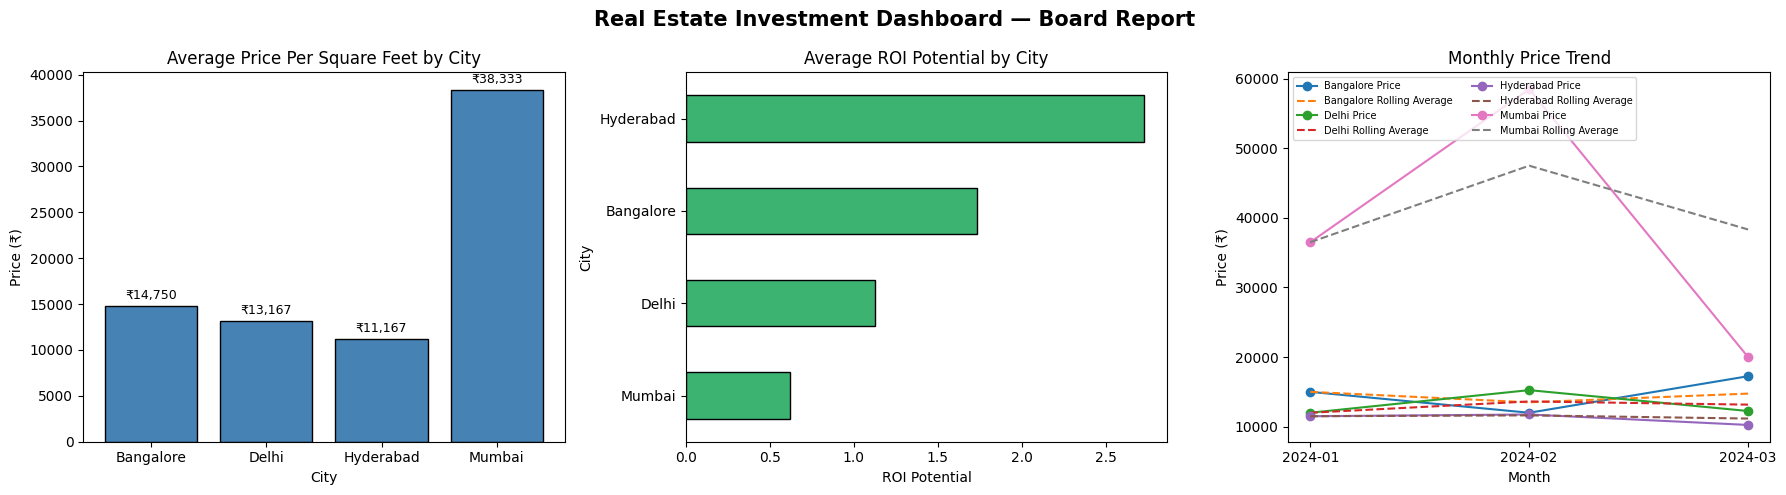

In [17]:
# Create 3 charts in one dashboard
figure, (price_chart, roi_chart, trend_chart) = plt.subplots(1, 3, figsize = (18,5))

# Chart 1 — Avg Price by City
average_price = data_frame_merged.groupby('City')['Price_Per_Sqft'].mean()

bars = price_chart.bar(average_price.index, average_price.values, color = 'steelblue', edgecolor = 'black')

price_chart.set_title('Average Price Per Square Feet by City')

price_chart.set_xlabel('City')

price_chart.set_ylabel('Price (₹)')

for bar in bars:
    height = bar.get_height()
    price_chart.annotate(f'₹{height:,.0f}', xy = (bar.get_x() + bar.get_width() / 2, height),
                         xytext = (0, 5), textcoords = 'offset points', ha = 'center', fontsize = 9)

# Chart 2 — ROI Potential by City
city_roi.sort_values().plot(kind = 'barh', ax = roi_chart, color = 'mediumseagreen', edgecolor = 'black')

roi_chart.set_title('Average ROI Potential by City')

roi_chart.set_xlabel('ROI Potential')

# Chart 3 — Monthly Trend
for city in monthly['City'].unique():
    subset = monthly[monthly['City'] == city]
    trend_chart.plot(subset['Listing_Month'], subset['Price_Per_Sqft'], marker = 'o', label = f'{city} Price')
    trend_chart.plot(subset['Listing_Month'], subset['Rolling_Average'], linestyle = '--', label = f'{city} Rolling Average')

trend_chart.set_title('Monthly Price Trend')

trend_chart.set_xlabel('Month')

trend_chart.set_ylabel('Price (₹)')

trend_chart.legend(loc = 'upper left', fontsize = 7, ncol = 2)

# Add overall title and save dashboard
plt.suptitle('Real Estate Investment Dashboard — Board Report', fontsize = 15, fontweight = 'bold')

plt.tight_layout()

plt.savefig('10_Insights_Real_Estate_Dashboard.png')

plt.show()

#### `Step 12 :- Print Outputs`

In [18]:
# Print all final outputs clearly using f-strings with single quotes
print('\n--- FINAL OUTPUTS ---')

# Final merged dataset shape
print(f'\n(Total_Property_Value, Price_Flag, Investment_Score, ROI_Potential)')

print(f'\nwill increase the final shape to:\n{data_frame_merged.shape}')

# Null values check
print(f'\nNull Values:\n{data_frame_merged.isnull().sum()}')

# Total Property Value sample
print(f'\nTotal Property Value (first 5 rows):\n{data_frame_merged[['Property_ID','City','Total_Property_Value']].head()}')

# IQR bounds and Price Flag counts
print(f'\nIQR Bounds: Q1={Q1}, Q3={Q3}, IQR={IQR}, Upper={upper_bound}')

print(f'\nPrice Flag Counts:\n{data_frame_merged['Price_Flag'].value_counts()}')

# Investment Score counts
print(f'\nInvestment Score Counts:\n{data_frame_merged['Investment_Score'].value_counts()}')

# Correlation scalar value
print(f'\nCorrelation (Locality Rating vs Price/Sqft): {correlation.iloc[0,1]:.4f}')

# Pivot table of avg price per sqft
print(f'\nPivot Table (Avg Price/Sqft by City & Property Type):\n{pivot}')

# ROI Potential by City
print(f'\nROI Potential by City:\n{city_roi.sort_values(ascending=False)}')

# Monthly price trend sample
print(f'\nMonthly Price Trend (first 10 rows):\n{monthly.head(10)}')



--- FINAL OUTPUTS ---

(Total_Property_Value, Price_Flag, Investment_Score, ROI_Potential)

will increase the final shape to:
(24, 15)

Null Values:
Property_ID             0
City                    0
Locality                0
Property_Type           0
Price_Per_Sqft          0
Area_Sqft               0
Listing_Month           0
Locality_Rating         0
Infrastructure_Score    0
Price_Growth_%          0
Avg_Rental_Yield        0
Total_Property_Value    0
Price_Flag              0
Investment_Score        0
ROI_Potential           0
dtype: int64

Total Property Value (first 5 rows):
  Property_ID    City  Total_Property_Value
0        PR01  Mumbai              23800000
1        PR02  Mumbai              99000000
2        PR03  Mumbai              30400000
3        PR04  Mumbai             297500000
4        PR05  Mumbai              17160000

IQR Bounds: Q1=9875.0, Q3=22000.0, IQR=12125.0, Upper=40187.5

Price Flag Counts:
Price_Flag
Fair Value    22
Overpriced     2
Name: count, dtyp

#### `Information`
> Listings = 24 rows

> Growth = 4 rows

> Ratings = 24 rows

> Final merged dataset = 24 rows × 15 columns

#### `Data Insights`
> Final merged dataset contains 24 rows and 15 columns.

> Overpriced properties = Mumbai Penthouse (₹85,000) + Mumbai Villa (₹45,000).

> Highest price growth = Hyderabad (28.6%).

> Investment Score: High Potential = premium localities in Hyderabad & Bangalore.

> Correlation between locality rating and price per sqft ≈ 0.41 (weak-to-moderate positive).

> Pivot table shows Mumbai penthouse highest avg price (₹85,000/sqft).

> Highest ROI potential = Hyderabad apartments (~3.81).

> Monthly trend: Hyderabad shows steepest upward curve, Mumbai relatively flat.

#### `Business Insights`
> Hyderabad offers strongest growth and ROI → top investment destination.

> Bangalore also high growth (22.8%) with strong locality ratings.

> Mumbai properties overpriced, ROI weak → avoid premium penthouses.

> Delhi moderate growth, ROI lower → secondary priority.

#### `Risks`
> Overpriced luxury properties may erode returns.

> High-rated localities are expensive → affordability risk.

> Market volatility in Hyderabad could affect ROI.

#### `Opportunities`
> Focus ₹50 crore allocation on Hyderabad and Bangalore.

> Target apartments and mid-range properties for best ROI.

> Use locality ratings to balance premium vs affordable investments.

#### `Recommendations`
> Invest ₹20 crore in Hyderabad apartments  
> - Evidence: Growth 28.6%, ROI ~3.81.

> Invest ₹15 crore in Bangalore apartments/villas  
> - Evidence: Growth 22.8%, strong ratings.

> Invest ₹10 crore in Delhi apartments  
> - Evidence: Moderate growth, stable yield.

> Avoid Mumbai penthouses/villas  
> - Evidence: Overpriced, ROI ~0.22.

> Reserve ₹5 crore for opportunistic Bangalore villa acquisition  
> - Evidence: Flexibility for market dips.

#### `Expected Business Impact`
> Optimized allocation of ₹50 crore → maximize ROI.

> Balanced portfolio across growth and stability.

> Reduced risk by avoiding overpriced luxury properties.

#### `Future Prediction`
> Hyderabad prices likely to continue upward trend.

> Bangalore to remain strong tech-driven market.

> Delhi stable but slower growth.

> Mumbai luxury segment correction expected.